In [79]:
import os
import random
import numpy as np
import pandas as pd
from collections import defaultdict

from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score




import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from collections import defaultdict

In [80]:
class DatasetLoader:
    def __init__(self, dataset_name):
        self.dataset_name = dataset_name
        self.base_dir = os.path.join(os.getcwd(), dataset_name)

    def load(self):
        if self.dataset_name == "MDRF":
            return self._load_mdrf()
        elif self.dataset_name == "LSGT":
            return self._load_lsgt()
        elif self.dataset_name == "PSnoD":
            return self._load_psnod()
        else:
            raise ValueError("Unsupported dataset")

    def _load_mdrf(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_semantic_similarity.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_similarity_.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'known_snoRNA_disease.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, :].values,
            relation.iloc[:, 1:].values
        )

    def _load_lsgt(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_similarity.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_similarity.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'known_snoRNA_disease.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, 1:].values,
            relation.iloc[:, 1:].T.values
        )

    def _load_psnod(self):
        disease = pd.read_csv(os.path.join(self.base_dir, 'disease_sim_graph_filtered.csv'))
        snoRNA = pd.read_csv(os.path.join(self.base_dir, 'snoRNA_4mer_similarity.csv'))
        relation = pd.read_csv(os.path.join(self.base_dir, 'relationship_matrix_filtered.csv'))

        return (
            disease.iloc[:, 1:].values,
            snoRNA.iloc[:, 1:].values,
            relation.iloc[:, 1:].T.values
            
        )


In [81]:
class NegativeSampler:
    def __init__(self, disease_sim, rna_sim, adj_matrix, random_state=0):
        self.disease_sim = disease_sim
        self.rna_sim = rna_sim
        self.adj_matrix = adj_matrix
        self.random_state = random_state


    def _split_known_unknown(self):
        known, unknown = [], []

        for r in range(self.adj_matrix.shape[0]):
            for d in range(self.adj_matrix.shape[1]):
                if self.adj_matrix[r, d] == 0:
                    unknown.append((r, d))
                else:
                    known.append((r, d))

        return known, unknown


    def _build_feature_vectors(self, pairs):
        features = []

        for r, d in pairs:
            disease_vec = self.disease_sim[d]
            rna_vec = self.rna_sim[r]
            features.append(np.concatenate([disease_vec, rna_vec]))

        return np.array(features)


    def build_unknown_feature_matrix(self):
        _, unknown = self._split_known_unknown()
        return self._build_feature_vectors(unknown)


    def find_optimal_k(self, k_range):
        feature_matrix = self.build_unknown_feature_matrix()

        sil_scores = []

        print("\nRunning Silhouette Analysis...\n")

        for k in k_range:
            kmeans = KMeans(
                n_clusters=k,
                random_state=self.random_state,
                n_init=10
            )

            labels = kmeans.fit_predict(feature_matrix)
            score = silhouette_score(feature_matrix, labels)
            sil_scores.append(score)

            print(f"k = {k} | Silhouette Score = {score:.4f}")


        knee = KneeLocator(
            list(k_range),
            sil_scores,
            curve="concave",
            direction="increasing"
        )

        optimal_k = knee.knee

        if optimal_k is None:
            optimal_k = k_range[np.argmax(sil_scores)]
            print("\nKnee not detected. Using maximum silhouette score.")

        print(f"\nOptimal k selected: {optimal_k}")

        return optimal_k, sil_scores


    def sample_with_k(self, n_clusters):
        known, unknown = self._split_known_unknown()
        feature_matrix = self._build_feature_vectors(unknown)

        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=self.random_state,
            n_init=10
        ).fit(feature_matrix)

        cluster_map = defaultdict(list)

        for pair, label in zip(unknown, kmeans.labels_):
            cluster_map[label].append(pair)

        sampled_unknown = []
        target_size = len(known)

        for c in cluster_map:
            n = int((len(cluster_map[c]) / len(unknown)) * target_size)
            sampled_unknown.extend(
                random.sample(cluster_map[c],
                              min(n, len(cluster_map[c])))
            )

        return known, sampled_unknown

In [82]:
class AssociationDatasetBuilder:
    def __init__(self, disease_sim, rna_sim):
        self.disease_sim = disease_sim
        self.rna_sim = rna_sim

    def build(self, known, sampled_unknown):
        dataset = known + sampled_unknown

        X, y = [], []
        known_set = set(known)

        for r, d in dataset:
            a = self.disease_sim[d].tolist()
            b = self.rna_sim[r].tolist()
            X.append(a + b)
            y.append(1 if (r, d) in known_set else 0)

        return np.array(X), np.array(y)


In [83]:
from abc import ABC, abstractmethod

class HybridModel(ABC):
    """
    Encoder + classifier abstraction
    """

    @abstractmethod
    def fit_encoder(self, X, y):
        pass

    @abstractmethod
    def transform(self, X):
        pass

    @abstractmethod
    def get_estimator(self):
        pass

    @abstractmethod
    def get_param_grid(self):
        pass


In [84]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def find_optimal_k(feature_matrix, k_range):
    scores = []

    for k in k_range:
        print(f"Evaluating k = {k}")
        kmeans = KMeans(n_clusters=k, random_state=0)
        labels = kmeans.fit_predict(feature_matrix)

        score = silhouette_score(feature_matrix, labels)
        scores.append(score)

        print(f"Silhouette Score for k={k}: {score:.4f}")

    return scores

def build_bipartite_edge_index(adj):
    r, d = np.nonzero(adj)
    d = d + adj.shape[0]
    edge_index = np.vstack([
        np.concatenate([r, d]),
        np.concatenate([d, r])
    ])
    return torch.tensor(edge_index, dtype=torch.long)


def build_node_features(rna_sim, disease_sim, out_dim=128):
    rna_proj = torch.nn.Linear(rna_sim.shape[1], out_dim, bias=False)
    dis_proj = torch.nn.Linear(disease_sim.shape[1], out_dim, bias=False)

    with torch.no_grad():
        rna_feat = rna_proj(torch.tensor(rna_sim, dtype=torch.float))
        dis_feat = dis_proj(torch.tensor(disease_sim, dtype=torch.float))
        # print(f"RNA feature shape: {rna_feat.shape}, Disease feature shape: {dis_feat.shape}")

    return torch.cat([rna_feat, dis_feat], dim=0)


def convert_edges_to_node_pairs(edges, rna_count):
    r = edges[:, 0] #3
    d = edges[:, 1] + rna_count # 336
    # print(f"Converted {len(edges)} edges to node pairs with RNA count offset {rna_count}")
    
    return torch.tensor(np.vstack([r, d]), dtype=torch.long)

def predict_single_pair(model, X, E, rna_id, disease_id, rna_count):
    model.eval()

    rna_node = torch.tensor([rna_id])
    disease_node = torch.tensor([disease_id + rna_count])

    pairs = torch.stack([rna_node, disease_node], dim=0)

    with torch.no_grad():
        prob = model(X, E, pairs)

    return float(prob.item())



In [85]:
class GCNEncoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.c1 = GCNConv(dim, 64)
        self.c2 = GCNConv(64, 64)

    def forward(self, x, e):
        return self.c2(F.relu(self.c1(x, e)), e)



In [86]:
class EdgeDecoder(nn.Module):
    def forward(self, z, p):
        return torch.sigmoid((z[p[0]] * z[p[1]]).sum(dim=1))

In [87]:
class BipartiteGNN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.enc = GCNEncoder(dim)
        self.dec = EdgeDecoder()

    def forward(self, x, e, p):
        return self.dec(self.enc(x, e), p)


In [88]:
class GNN_Evaluator:
    def __init__(self, disease, rna, adj, pos, neg, folds):
        self.rna_count = rna.shape[0]

        self.X = build_node_features(rna, disease)


        self.E = build_bipartite_edge_index(adj)


        self.edges = np.vstack([pos, neg])
        self.labels = np.hstack([
            np.ones(len(pos)),
            np.zeros(len(neg))
        ])

        self.cv = StratifiedKFold(
            n_splits=folds,
            shuffle=True,
            random_state=42
        )

    def evaluate(self):
        aucs, accs, yt, yp = [], [], [], []
        

        for tr, te in self.cv.split(self.edges, self.labels):
            model = BipartiteGNN(self.X.shape[1])
            opt = torch.optim.Adam(model.parameters(), lr=0.01)
            loss_fn = nn.BCELoss()

            for _ in range(200):
                opt.zero_grad()

                pairs = convert_edges_to_node_pairs(
                    self.edges[tr], self.rna_count
                )
                y = torch.tensor(self.labels[tr], dtype=torch.float)
                preds = model(self.X, self.E, pairs)
                loss = loss_fn(preds, y)
                loss.backward()
                opt.step()

            with torch.no_grad():
                pairs = convert_edges_to_node_pairs(
                    self.edges[te], self.rna_count
                )
                preds = model(self.X, self.E, pairs).cpu().numpy()

            aucs.append(roc_auc_score(self.labels[te], preds))
            accs.append(accuracy_score(self.labels[te], preds > 0.5))

            yt.extend(self.labels[te])
            yp.extend(preds > 0.5)

        return (
            float(np.mean(aucs)),
            float(np.mean(accs)),
            float(f1_score(yt, yp))
        )


In [89]:
# DATASET = "PSnoD"
# MODEL = "GNN"
# FOLDS = 5
# CLUSTERS = range(2, 31)

# disease, rna, adj = DatasetLoader(DATASET).load()

In [90]:
# disease.shape, rna.shape, adj.shape

In [91]:
class ModelEvaluator:
    def __init__(self, hybrid_model, n_splits=5, scoring="roc_auc", random_state=42):
        self.model = hybrid_model
        self.cv = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )
        self.scoring = scoring

    def evaluate(self, X, y):
        aucs, accs, f1s = [], [], []

        for fold, (train_idx, test_idx) in enumerate(self.cv.split(X, y), 1):

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]


            self.model.fit_encoder(X_train, y_train)

            X_train_enc = self.model.transform(X_train)
            X_test_enc = self.model.transform(X_test)


            grid = GridSearchCV(
                estimator=self.model.get_estimator(),
                param_grid=self.model.get_param_grid(),
                scoring=self.scoring,
                cv=3,
                n_jobs=-1
            )

            grid.fit(X_train_enc, y_train)
            best = grid.best_estimator_


            probs = best.predict_proba(X_test_enc)[:, 1]
            preds = best.predict(X_test_enc)

            fold_auc = roc_auc_score(y_test, probs)
            fold_acc = accuracy_score(y_test, preds)
            fold_f1 = f1_score(y_test, preds)

            aucs.append(fold_auc)
            accs.append(fold_acc)
            f1s.append(fold_f1)

            print(
                f"Fold {fold}: "
                f"AUC={fold_auc:.4f} | "
                f"ACC={fold_acc:.4f} | "
                f"F1={fold_f1:.4f}"
            )

        return {
            "mean_auc": float(np.mean(aucs)),
            "std_auc": float(np.std(aucs)),
            "mean_accuracy": float(np.mean(accs)),
            "mean_f1": float(np.mean(f1s))
        }

In [92]:
dataset = "MDRF" 
disease_sim, rna_sim, adj = DatasetLoader(dataset).load()
rna_count, disease_count = rna_sim.shape[0], disease_sim.shape[0]
disease_names = pd.read_csv(os.path.join(os.getcwd(), dataset, "disease_semantic_similarity.csv")).columns[1:]
rna_names = pd.read_csv(os.path.join(os.getcwd(), dataset, "all_snoRNA_name.csv"),header=None).iloc[:, 0].tolist()

In [93]:
rna_names

['GAS5',
 'MEG8',
 'RNU1-1',
 'RNU1-2',
 'RNU1-3',
 'RNU1-4',
 'RNU2-1',
 'RNU7-1',
 'RNVU1-18',
 'RNVU1-7',
 'SCARNA10',
 'SCARNA11',
 'SCARNA12',
 'SCARNA13',
 'SCARNA14',
 'SCARNA15',
 'SCARNA16',
 'SCARNA17',
 'SCARNA18',
 'SCARNA2',
 'SCARNA22',
 'SCARNA3',
 'SCARNA4',
 'SCARNA5',
 'SCARNA7',
 'SCARNA8',
 'SCARNA9',
 'SNHG1',
 'SNHG10',
 'SNHG11',
 'SNHG12',
 'SNHG14',
 'SNHG15',
 'SNHG16',
 'SNHG17',
 'SNHG18',
 'SNHG19',
 'SNHG20',
 'SNHG21',
 'SNHG22',
 'SNHG25',
 'SNHG3',
 'SNHG4',
 'SNHG5',
 'SNHG6',
 'SNHG7',
 'SNHG8',
 'SNHG9',
 'SNORA1',
 'SNORA11E',
 'SNORA13',
 'SNORA14A',
 'SNORA14B',
 'SNORA15',
 'SNORA16A',
 'SNORA16B',
 'SNORA17A',
 'SNORA17B',
 'SNORA18',
 'SNORA20',
 'SNORA21',
 'SNORA22',
 'SNORA23',
 'SNORA24',
 'SNORA25',
 'SNORA26',
 'SNORA27',
 'SNORA28',
 'SNORA29',
 'SNORA2B',
 'SNORA30',
 'SNORA31',
 'SNORA32',
 'SNORA33',
 'SNORA35',
 'SNORA36A',
 'SNORA36C',
 'SNORA37',
 'SNORA3A',
 'SNORA3B',
 'SNORA4',
 'SNORA40',
 'SNORA41',
 'SNORA44',
 'SNORA46',
 'S

In [94]:
disease_sim.shape, rna_sim.shape, adj.shape, len(disease_names), len(rna_names)

((112, 112), (335, 335), (335, 112), 112, 335)

In [95]:

edge_index_full = torch.tensor(
    np.vstack(np.nonzero(adj)),
    dtype=torch.long
)


Running Silhouette Analysis...

k = 7 | Silhouette Score = 0.1046
k = 8 | Silhouette Score = 0.1101
k = 9 | Silhouette Score = 0.1037
k = 10 | Silhouette Score = 0.1061
k = 11 | Silhouette Score = 0.0898

Optimal k selected: 8


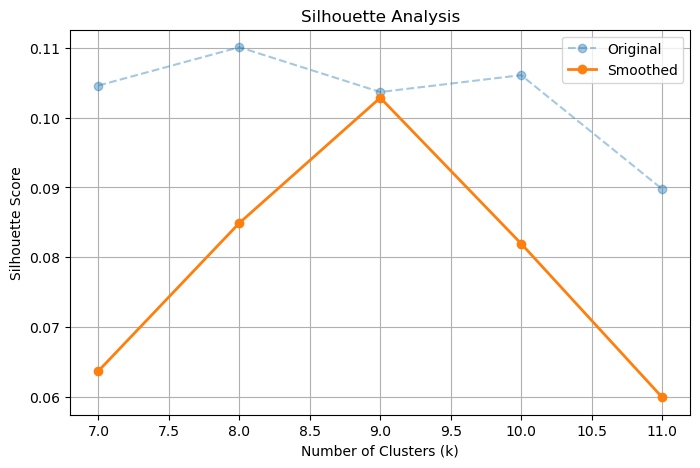

Positive samples: 1010, Negative samples: 1006


In [96]:
import numpy as np
import matplotlib.pyplot as plt


sampler = NegativeSampler(disease_sim, rna_sim, adj, random_state=42)


k_range = range(7, 12)
k = np.array(list(k_range))
scores = sampler.find_optimal_k(k_range)[1]


window = 5
scores_smooth = np.convolve(scores, np.ones(window) / window, mode='same')


plt.figure(figsize=(8, 5))
plt.plot(k, scores, 'o--', alpha=0.4, label='Original')
plt.plot(k, scores_smooth, '-o', linewidth=2, label='Smoothed')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.legend()
plt.show()


optimal_k = k[np.argmax(scores_smooth)]
pos, neg = sampler.sample_with_k(optimal_k)

# print(f"Optimal k selected: {optimal_k}")
print(f"Positive samples: {len(pos)}, Negative samples: {len(neg)}")

In [97]:

X = build_node_features(rna_sim, disease_sim)
E = build_bipartite_edge_index(adj)

In [98]:

edges = np.vstack([pos, neg])
labels = np.hstack([np.ones(len(pos)), np.zeros(len(neg))])
edges = edges.astype(int)
labels = labels.astype(float)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [99]:

aucs, accs, f1s = [], [], []

for train_idx, test_idx in skf.split(edges, labels):

    model = BipartiteGNN(dim=X.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    train_pairs = convert_edges_to_node_pairs(edges[train_idx], rna_count)
    train_y = torch.tensor(labels[train_idx], dtype=torch.float)

    for epoch in range(200):
        opt.zero_grad()
        preds = model(X, E, train_pairs)
        loss = loss_fn(preds, train_y)
        loss.backward()
        opt.step()

    # test
    test_pairs = convert_edges_to_node_pairs(edges[test_idx], rna_count)
    with torch.no_grad():
        preds = model(X, E, test_pairs).cpu().numpy()

    y_true = labels[test_idx]
    y_pred = (preds > 0.5).astype(int)

    aucs.append(roc_auc_score(y_true, preds))
    accs.append(accuracy_score(y_true, y_pred))
    f1s.append(f1_score(y_true, y_pred))
    print(
        f"AUC: {aucs[-1]:.4f} | "
        f"ACC: {accs[-1]:.4f} | "
        f"F1: {f1s[-1]:.4f}"
    )

AUC: 0.9703 | ACC: 0.9282 | F1: 0.9280
AUC: 0.9322 | ACC: 0.8734 | F1: 0.8759
AUC: 0.9599 | ACC: 0.9057 | F1: 0.9095
AUC: 0.9762 | ACC: 0.9355 | F1: 0.9366
AUC: 0.9565 | ACC: 0.8958 | F1: 0.8976


In [100]:

final_model = BipartiteGNN(dim=X.shape[1])
opt = torch.optim.Adam(final_model.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

train_pairs = convert_edges_to_node_pairs(edges, rna_count)
train_y = torch.tensor(labels, dtype=torch.float)

for epoch in range(300):
    opt.zero_grad()
    preds = final_model(X, E, train_pairs)
    loss = loss_fn(preds, train_y)
    loss.backward()
    opt.step()

In [101]:

unknown_pairs = [(r, d) for r in range(rna_count) for d in range(disease_count) if adj[r, d] == 0]
scores = []

with torch.no_grad():
    for (r, d) in unknown_pairs:
        pair = torch.tensor([[r], [d + rna_count]])
        score = final_model(X, E, pair).item()
        scores.append((r, d, score))

# sort by score descending
scores_sorted = sorted(scores, key=lambda x: x[2], reverse=True)

In [102]:

df = pd.DataFrame(scores_sorted, columns=["RNA_ID", "Disease_ID", "Score"])
df.to_csv(os.path.join(dataset, "unknown_predictions_gnn.csv"), index=False)

df[df.Score >= 0.75].to_csv(os.path.join(dataset, "unknown_predictions_gnn_75.csv"), index=False)

In [104]:
rna_names[0], disease_names[34]

('GAS5', 'Gastric cancer')